In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
from sklearn.preprocessing import StandardScaler

In [ ]:
data = pd.read_csv("TrainingWiDS2021.csv")

In [ ]:
data

,Unnamed: 0,encounter_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,...,h1_pao2fio2ratio_max,h1_pao2fio2ratio_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus
0,1,214826,118,68.0,22.732803,0,Caucasian,M,180.3,Floor,...,NaN,NaN,0,0,0,0,0,0,0,1
1,2,246060,81,77.0,27.421875,0,Caucasian,F,160.0,Floor,...,51.0,51.0,0,0,0,0,0,0,0,1
2,3,276985,118,25.0,31.952749,0,Caucasian,F,172.7,Emergency Department,...,NaN,NaN,0,0,0,0,0,0,0,0
3,4,262220,118,81.0,22.635548,1,Caucasian,F,165.1,Operating Room,...,337.0,337.0,0,0,0,0,0,0,0,0
4,5,201746,33,19.0,NaN,0,Caucasian,M,188.0,NaN,...,NaN,NaN,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130152,130153,164758,7,50.0,29.287256,0,Caucasian,M,175.3,Emergency Department,...,NaN,NaN,0,0,0,0,0,0,0,0
130153,130154,197653,7,79.0,29.653433,0,Caucasian,F,162.6,Direct Admit,...,NaN,NaN,0,0,0,0,0,0,0,0
130154,130155,219719,7,73.0,32.265371,0,African American,M,177.8,Emergency Department,...,163.0,163.0,0,0,0,0,0,0,0,1
130155,130156,222562,170,81.0,24.408579,0,Caucasian,M,185.4,Emergency Department,...,NaN,NaN,0,0,0,0,0,0,0,0


In [ ]:
data.columns.tolist()

['Unnamed: 0',
 'encounter_id',
 'hospital_id',
 'age',
 'bmi',
 'elective_surgery',
 'ethnicity',
 'gender',
 'height',
 'hospital_admit_source',
 'icu_admit_source',
 'icu_id',
 'icu_stay_type',
 'icu_type',
 'pre_icu_los_days',
 'readmission_status',
 'weight',
 'albumin_apache',
 'apache_2_diagnosis',
 'apache_3j_diagnosis',
 'apache_post_operative',
 'arf_apache',
 'bilirubin_apache',
 'bun_apache',
 'creatinine_apache',
 'fio2_apache',
 'gcs_eyes_apache',
 'gcs_motor_apache',
 'gcs_unable_apache',
 'gcs_verbal_apache',
 'glucose_apache',
 'heart_rate_apache',
 'hematocrit_apache',
 'intubated_apache',
 'map_apache',
 'paco2_apache',
 'paco2_for_ph_apache',
 'pao2_apache',
 'ph_apache',
 'resprate_apache',
 'sodium_apache',
 'temp_apache',
 'urineoutput_apache',
 'ventilated_apache',
 'wbc_apache',
 'd1_diasbp_invasive_max',
 'd1_diasbp_invasive_min',
 'd1_diasbp_max',
 'd1_diasbp_min',
 'd1_diasbp_noninvasive_max',
 'd1_diasbp_noninvasive_min',
 'd1_heartrate_max',
 'd1_heartrate

In [ ]:
data.shape

(130157, 181)

In [ ]:
data.isnull().sum()

Unnamed: 0                        0
encounter_id                      0
hospital_id                       0
age                            4988
bmi                            4490
                               ... 
immunosuppression                 0
leukemia                          0
lymphoma                          0
solid_tumor_with_metastasis       0
diabetes_mellitus                 0
Length: 181, dtype: int64

In [ ]:
data.isna().sum()

Unnamed: 0                        0
encounter_id                      0
hospital_id                       0
age                            4988
bmi                            4490
                               ... 
immunosuppression                 0
leukemia                          0
lymphoma                          0
solid_tumor_with_metastasis       0
diabetes_mellitus                 0
Length: 181, dtype: int64

In [ ]:
(data == "?").sum().tolist()

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [ ]:
data.isna().sum()

Unnamed: 0                        0
encounter_id                      0
hospital_id                       0
age                            4988
bmi                            4490
                               ... 
immunosuppression                 0
leukemia                          0
lymphoma                          0
solid_tumor_with_metastasis       0
diabetes_mellitus                 0
Length: 181, dtype: int64

In [ ]:
data["age"].dropna()

0         68.0
1         77.0
2         25.0
3         81.0
4         19.0
          ... 
130152    50.0
130153    79.0
130154    73.0
130155    81.0
130156    35.0
Name: age, Length: 125169, dtype: float64

In [ ]:
data['age'].isnull().sum()

np.int64(4988)

In [89]:
data['age'].tolist()

[68.0,
 77.0,
 25.0,
 81.0,
 19.0,
 67.0,
 59.0,
 70.0,
 45.0,
 50.0,
 72.0,
 80.0,
 48.0,
 65.0,
 81.0,
 78.0,
 30.0,
 46.0,
 65.0,
 39.0,
 79.0,
 80.0,
 58.0,
 87.0,
 60.0,
 68.0,
 85.0,
 79.0,
 nan,
 60.0,
 76.0,
 68.0,
 30.0,
 45.0,
 53.0,
 71.0,
 71.0,
 58.0,
 85.0,
 65.0,
 82.0,
 60.0,
 87.0,
 52.0,
 60.0,
 75.0,
 64.0,
 59.0,
 55.0,
 67.0,
 75.0,
 53.0,
 73.0,
 88.0,
 84.0,
 68.0,
 62.0,
 81.0,
 55.0,
 56.0,
 85.0,
 77.0,
 38.0,
 73.0,
 59.0,
 41.0,
 70.0,
 35.0,
 54.0,
 58.0,
 48.0,
 80.0,
 nan,
 74.0,
 59.0,
 84.0,
 67.0,
 73.0,
 65.0,
 82.0,
 81.0,
 49.0,
 85.0,
 56.0,
 67.0,
 62.0,
 52.0,
 30.0,
 78.0,
 88.0,
 68.0,
 86.0,
 85.0,
 65.0,
 51.0,
 55.0,
 35.0,
 63.0,
 68.0,
 25.0,
 84.0,
 61.0,
 65.0,
 71.0,
 71.0,
 72.0,
 47.0,
 75.0,
 55.0,
 33.0,
 65.0,
 89.0,
 74.0,
 48.0,
 73.0,
 73.0,
 68.0,
 75.0,
 84.0,
 50.0,
 36.0,
 89.0,
 68.0,
 69.0,
 72.0,
 71.0,
 69.0,
 74.0,
 65.0,
 72.0,
 54.0,
 84.0,
 86.0,
 56.0,
 78.0,
 72.0,
 64.0,
 58.0,
 55.0,
 46.0,
 69.0,
 63.0,
 75.0,
 

AttributeError: 'NoneType' object has no attribute 'describe'

In [ ]:
data.isna().sum()

Unnamed: 0                        0
encounter_id                      0
hospital_id                       0
age                            4988
bmi                            4490
                               ... 
immunosuppression                 0
leukemia                          0
lymphoma                          0
solid_tumor_with_metastasis       0
diabetes_mellitus                 0
Length: 181, dtype: int64

In [123]:
data_clean = data.replace(['nan', 'NaN'], np.nan, inplace = True)

In [124]:
# Drop columns where more than 40% of values are missing
threshold = 0.4

# Drop coulmns with 0.4 threshold missing values
data_clean = data_clean.dropna( thresh = len(data) * (1 - threshold), axis=1)

AttributeError: 'NoneType' object has no attribute 'dropna'

In [ ]:
num_cols = data_clean.select_dtypes(include = 'number').columns


In [ ]:
data_clean[num_cols] = data_clean[num_cols].fillna(data_clean[num_cols].median())

In [ ]:
print(data_clean.shape)
print(data_clean.isna().sum().sum())

(130157, 107)
35091


In [ ]:
data_clean.isnull().sum().tolist()


[0,
 0,
 0,
 0,
 0,
 0,
 1587,
 66,
 0,
 33198,
 240,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [ ]:
(data_clean == '?').sum().tolist()

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [ ]:
data_clean.isna().sum()

Unnamed: 0                     0
encounter_id                   0
hospital_id                    0
age                            0
bmi                            0
                              ..
immunosuppression              0
leukemia                       0
lymphoma                       0
solid_tumor_with_metastasis    0
diabetes_mellitus              0
Length: 107, dtype: int64

In [ ]:
data_clean.isna().sum()

Unnamed: 0                     0
encounter_id                   0
hospital_id                    0
age                            0
bmi                            0
                              ..
immunosuppression              0
leukemia                       0
lymphoma                       0
solid_tumor_with_metastasis    0
diabetes_mellitus              0
Length: 107, dtype: int64

In [ ]:
data_clean.head()

,Unnamed: 0,encounter_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,...,d1_wbc_max,d1_wbc_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus
0,1,214826,118,68.0,22.732803,0,Caucasian,M,180.3,Floor,...,14.1,14.1,0,0,0,0,0,0,0,1
1,2,246060,81,77.0,27.421875,0,Caucasian,F,160.0,Floor,...,23.3,12.7,0,0,0,0,0,0,0,1
2,3,276985,118,25.0,31.952749,0,Caucasian,F,172.7,Emergency Department,...,11.1,10.1,0,0,0,0,0,0,0,0
3,4,262220,118,81.0,22.635548,1,Caucasian,F,165.1,Operating Room,...,9.0,8.0,0,0,0,0,0,0,0,0
4,5,201746,33,19.0,27.564749,0,Caucasian,M,188.0,NaN,...,11.1,10.1,0,0,0,0,0,0,0,0


In [ ]:
data_clean = data_clean.drop([
    'Unnamed: 0',
    'encounter_id',
    'hospital_id',
    'ethnicity',
    'gender',
    'hospital_admit_source',
    'icu_admit_source',
    'icu_id',
    'icu_type',
    'pre_icu_los_days'
], axis=1)

In [ ]:
data_clean

,age,bmi,elective_surgery,height,icu_stay_type,readmission_status,weight,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,...,d1_wbc_max,d1_wbc_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus
0,68.0,22.732803,0,180.3,admit,0,73.9,113.0,502.01,0,...,14.1,14.1,0,0,0,0,0,0,0,1
1,77.0,27.421875,0,160.0,admit,0,70.2,108.0,203.01,0,...,23.3,12.7,0,0,0,0,0,0,0,1
2,25.0,31.952749,0,172.7,admit,0,95.3,122.0,703.03,0,...,11.1,10.1,0,0,0,0,0,0,0,0
3,81.0,22.635548,1,165.1,admit,0,61.7,203.0,1206.03,1,...,9.0,8.0,0,0,0,0,0,0,0,0
4,19.0,27.564749,0,188.0,admit,0,80.0,119.0,601.01,0,...,11.1,10.1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130152,50.0,29.287256,0,175.3,admit,0,90.0,110.0,104.01,0,...,11.1,10.1,0,0,0,0,0,0,0,0
130153,79.0,29.653433,0,162.6,admit,0,78.4,105.0,207.01,0,...,10.4,9.5,0,0,0,0,0,0,0,0
130154,73.0,32.265371,0,177.8,admit,0,102.0,114.0,102.01,0,...,41.8,20.4,0,0,0,0,0,0,0,1
130155,81.0,24.408579,0,185.4,admit,0,83.9,124.0,306.01,0,...,15.3,15.3,0,0,0,0,0,0,0,0


In [ ]:
data_clean.dtypes.tolist()

[dtype('float64'),
 dtype('float64'),
 dtype('int64'),
 dtype('float64'),
 dtype('O'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('int64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('flo

In [ ]:
data_clean.columns.to_list()

['age',
 'bmi',
 'elective_surgery',
 'height',
 'icu_stay_type',
 'readmission_status',
 'weight',
 'apache_2_diagnosis',
 'apache_3j_diagnosis',
 'apache_post_operative',
 'arf_apache',
 'bun_apache',
 'creatinine_apache',
 'gcs_eyes_apache',
 'gcs_motor_apache',
 'gcs_unable_apache',
 'gcs_verbal_apache',
 'glucose_apache',
 'heart_rate_apache',
 'hematocrit_apache',
 'intubated_apache',
 'map_apache',
 'resprate_apache',
 'sodium_apache',
 'temp_apache',
 'ventilated_apache',
 'wbc_apache',
 'd1_diasbp_max',
 'd1_diasbp_min',
 'd1_diasbp_noninvasive_max',
 'd1_diasbp_noninvasive_min',
 'd1_heartrate_max',
 'd1_heartrate_min',
 'd1_mbp_max',
 'd1_mbp_min',
 'd1_mbp_noninvasive_max',
 'd1_mbp_noninvasive_min',
 'd1_resprate_max',
 'd1_resprate_min',
 'd1_spo2_max',
 'd1_spo2_min',
 'd1_sysbp_max',
 'd1_sysbp_min',
 'd1_sysbp_noninvasive_max',
 'd1_sysbp_noninvasive_min',
 'd1_temp_max',
 'd1_temp_min',
 'h1_diasbp_max',
 'h1_diasbp_min',
 'h1_diasbp_noninvasive_max',
 'h1_diasbp_noni

In [ ]:
import matplotlib.pyplot as plt

(array([     0.,      0.,      0.,      0.,      0., 130157.,      0.,
             0.,      0.,      0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <BarContainer object of 10 artists>)

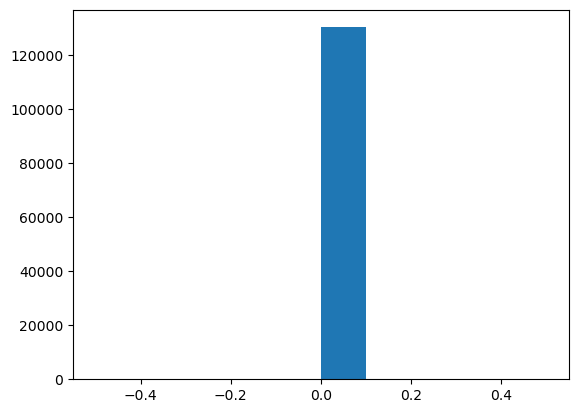

In [ ]:
plt.hist(data_clean['readmission_status'])       

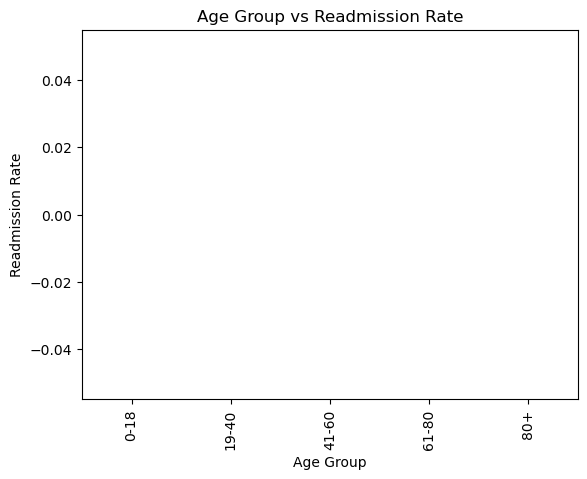

In [ ]:
data_clean['age_groups'] = pd.cut(data_clean['age'], 
    bins=[0, 18, 40, 60, 80, 120],
    labels=['0-18', '19-40', '41-60', '61-80', '80+'])

readmission_rate = data_clean.groupby('age_groups', observed=False)['readmission_status'].mean()

readmission_rate.plot(kind='bar')
plt.title("Age Group vs Readmission Rate")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate")
plt.show()

In [ ]:
data_clean.describe()


,age,bmi,elective_surgery,height,readmission_status,weight,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,arf_apache,...,d1_wbc_max,d1_wbc_min,aids,cirrhosis,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,diabetes_mellitus
count,130157.000000,130157.000000,130157.000000,130157.000000,130157.0,130157.000000,130157.000000,130157.000000,130157.000000,130157.000000,...,130157.000000,130157.000000,130157.00000,130157.000000,130157.000000,130157.000000,130157.000000,130157.000000,130157.000000,130157.000000
mean,62.071936,29.056944,0.189840,169.615083,0.0,83.690237,184.670713,564.951073,0.207111,0.027997,...,12.346890,11.138070,0.00103,0.016081,0.013599,0.025669,0.007307,0.004187,0.020852,0.216285
std,16.501866,8.123902,0.392176,10.746479,0.0,24.636289,85.602060,465.132980,0.405238,0.164965,...,6.331392,5.528791,0.03207,0.125786,0.115819,0.158146,0.085166,0.064574,0.142888,0.411712
min,0.000000,14.844926,0.000000,137.200000,0.0,38.600000,101.000000,0.010000,0.000000,0.000000,...,1.200000,0.900000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,53.000000,23.737886,0.000000,162.600000,0.0,67.000000,113.000000,206.010000,0.000000,0.000000,...,8.500000,7.900000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,64.000000,27.564749,0.000000,170.100000,0.0,80.000000,122.000000,409.020000,0.000000,0.000000,...,11.100000,10.100000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,74.000000,32.546205,0.000000,177.800000,0.0,96.100000,301.000000,703.030000,0.000000,0.000000,...,14.500000,13.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,89.000000,67.814990,1.000000,195.590000,0.0,186.000000,308.000000,2201.050000,1.000000,1.000000,...,46.080000,40.898000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
